### Load & Combine Data (2003–2022)

In [19]:
import pandas as pd
import os

base_path = "/vol/sandeep_storage/Files2/countries"
country = "Norway"
years = range(2003, 2023)  # 2003 to 2022

dataframes = []

for year in years:
    file_path = os.path.join(base_path, f"{year}_{country}_generation_curve.parquet")
    if os.path.exists(file_path):
        df_year = pd.read_parquet(file_path)
        df_year['year'] = year
        dataframes.append(df_year)
        print(f"Loaded: {file_path}")
    else:
        print(f"Skipped: {file_path}")

df = pd.concat(dataframes, ignore_index=True)
print("Combined Data Shape:", df.shape)
df.to_parquet("/vol/sandeep_storage/Files2/countries/norway_combined_2003_2022.parquet")  # Optional save


Loaded: /vol/sandeep_storage/Files2/countries/2003_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2004_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2005_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2006_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2007_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2008_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2009_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2010_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2011_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2012_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2013_Norway_generation_curve.parquet
Loaded: /vol/sandeep_storage/Files2/countries/2014_Norway_generation_curve.parquet
Load

In [20]:
data=pd.read_parquet('/vol/sandeep_storage/Files2/countries/norway_combined_2003_2022.parquet')
data


,valid_time,Latitude,Longitude,Rounded Wind Speed,Mapped Generation (MW),year
0,2003-01-01,56.75,2.25,9.1,1.199652,2003
1,2003-01-01,56.75,3.75,8.6,1.024000,2003
2,2003-01-01,56.75,4.25,8.6,1.024000,2003
3,2003-01-01,56.75,4.75,8.5,0.990000,2003
4,2003-01-01,56.75,5.00,8.4,0.956000,2003
...,...,...,...,...,...,...
27919705,2022-12-31,71.00,29.75,14.6,2.100000,2022
27919706,2022-12-31,71.00,30.00,14.8,2.100000,2022
27919707,2022-12-31,71.00,30.25,15.0,2.100000,2022
27919708,2022-12-31,71.00,30.50,15.2,2.100000,2022


###  Feature Engineering

In [21]:
df['day_of_year'] = pd.to_datetime(df['valid_time']).dt.dayofyear

features = ['Latitude', 'Longitude', 'Rounded Wind Speed', 'day_of_year']
target = 'Mapped Generation (MW)'

X = df[features]
y = df[target]

print(" Feature matrix X shape:", X.shape)
print(" Target y shape:", y.shape)


 Feature matrix X shape: (27919710, 4)
 Target y shape: (27919710,)


### Train/Test Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(" Training set size:", X_train.shape[0])
print(" Validation set size:", X_val.shape[0])


 Training set size: 22335768
 Validation set size: 5583942


### Train XGBoost Model

In [23]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='reg:squarederror',
    tree_method='hist'
)

model.fit(X_train, y_train)
print(" Model training complete")


/home/sandeep/.conda/envs/sahu/lib/python3.10/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


 Model training complete


### Evaluate Model

In [24]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_val)
rmse = mean_squared_error(y_val, y_pred, squared=False)
r2 = r2_score(y_val, y_pred)

print(f" RMSE: {rmse:.3f}")
print(f" R² Score: {r2:.3f}")


 RMSE: 0.024
 R² Score: 0.999


/home/sandeep/.conda/envs/sahu/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Analysis of trained XGBoost Model 

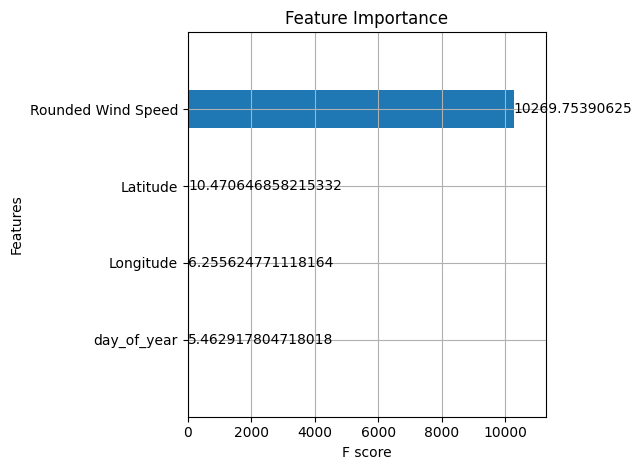

In [25]:
import matplotlib.pyplot as plt
import xgboost as xgb

# Plot gain-based feature importance
xgb.plot_importance(model, height=0.5, importance_type='gain', title='Feature Importance')
plt.tight_layout()
plt.show()


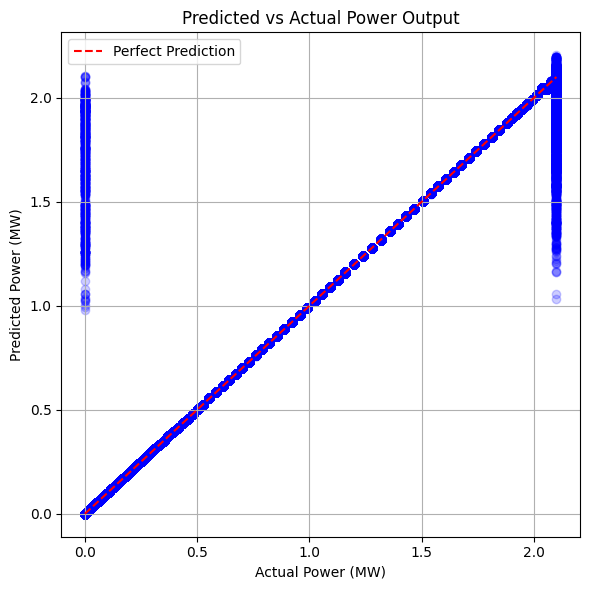

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.2, color='blue')
plt.plot([0, max(y_val)], [0, max(y_val)], '--', color='red', label='Perfect Prediction')
plt.xlabel("Actual Power (MW)")
plt.ylabel("Predicted Power (MW)")
plt.title("Predicted vs Actual Power Output")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


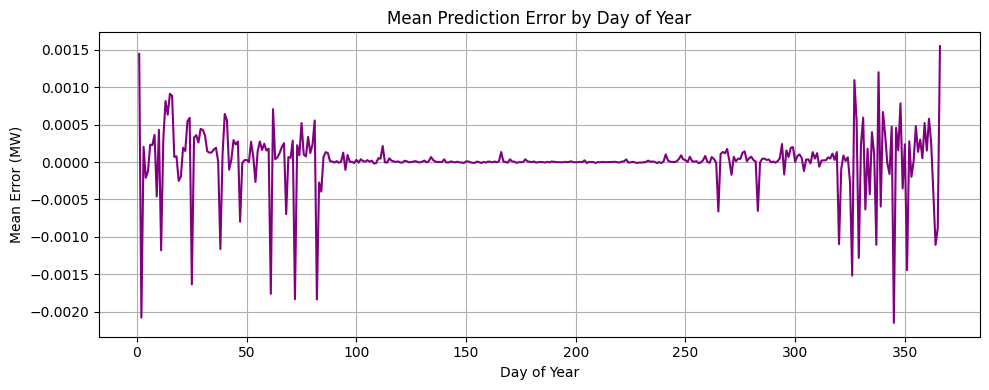

In [28]:
val_days = X_val['day_of_year']
error_by_day = pd.DataFrame({
    'day_of_year': val_days,
    'error': y_val - y_pred
})

day_error_mean = error_by_day.groupby('day_of_year')['error'].mean()

plt.figure(figsize=(10, 4))
plt.plot(day_error_mean.index, day_error_mean.values, color='purple')
plt.title("Mean Prediction Error by Day of Year")
plt.xlabel("Day of Year")
plt.ylabel("Mean Error (MW)")
plt.grid(True)
plt.tight_layout()
plt.show()


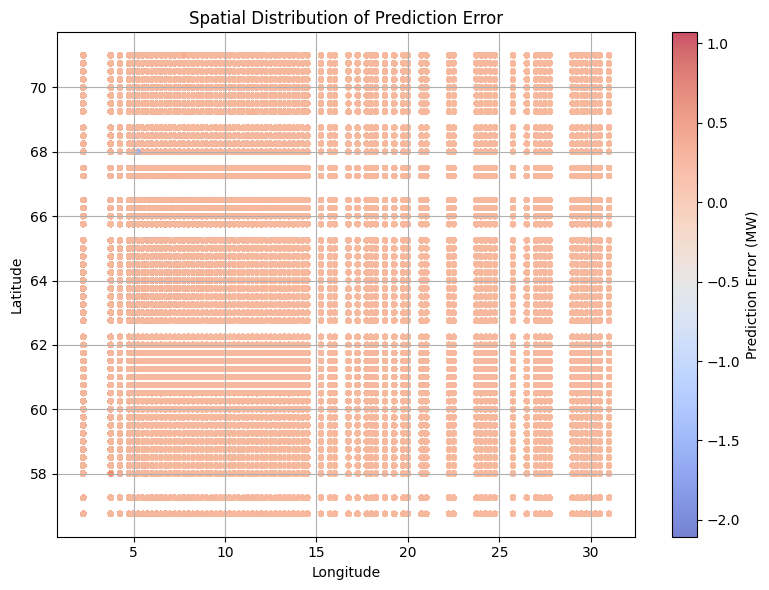

In [29]:
val_coords = X_val[['Latitude', 'Longitude']]
residuals_df = val_coords.copy()
residuals_df['error'] = y_val - y_pred

plt.figure(figsize=(8, 6))
sc = plt.scatter(residuals_df['Longitude'], residuals_df['Latitude'],
                 c=residuals_df['error'], cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(sc, label='Prediction Error (MW)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Prediction Error")
plt.grid(True)
plt.tight_layout()
plt.show()


### saving model

In [42]:
import joblib

joblib.dump(model, "/home/sandeep/wind_api/wind_power_xgb_model.pkl")
print(" Model saved as wind_power_xgb_model.pkl")


 Model saved as wind_power_xgb_model.pkl


### Power prediction for selected 5 sites in Norway and using real time wind speed from Open-Meteo (assuming a turbine of 2.1 MW is installed at all sites)

In [38]:
import pandas as pd
import numpy as np
import requests
import joblib
from datetime import datetime

# --- Load trained model
model = joblib.load("/vol/sandeep_storage/Files2/countries/wind_power_xgb_model.pkl")

# --- Ask user for a date
user_input = input("Enter date (YYYY-MM-DD) [default: today]: ").strip()
if user_input:
    forecast_date = user_input
else:
    forecast_date = datetime.today().strftime("%Y-%m-%d")

day_of_year = datetime.strptime(forecast_date, "%Y-%m-%d").timetuple().tm_yday

# --- Load wind farm coordinates
excel_file = "/vol/sandeep_storage/Files2/windpowerr.xlsx"
df = pd.read_excel(excel_file, sheet_name='Data')
df_norway = df[df['Country/Area'].str.strip().str.lower() == 'norway'].dropna(subset=['Latitude', 'Longitude'])
wind_farms = df_norway[['Latitude', 'Longitude']].head(5).reset_index(drop=True)

# --- Utility functions
def snap_to_grid(lat, lon, res=0.25):
    return round(lat / res) * res, round(lon / res) * res

def get_wind_speed(lat, lon, date):
    url = (
        f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}"
        f"&hourly=wind_speed_100m&timezone=auto&start_date={date}&end_date={date}"
    )
    try:
        r = requests.get(url)
        wind_speeds = r.json()["hourly"]["wind_speed_100m"]
        return wind_speeds[12]  # noon value
    except Exception as e:
        print(f" Error fetching wind for {lat},{lon}: {e}")
        return None

# --- Run prediction
results = []
for idx, row in wind_farms.iterrows():
    lat, lon = row['Latitude'], row['Longitude']
    lat_snap, lon_snap = snap_to_grid(lat, lon)
    wind_speed = get_wind_speed(lat_snap, lon_snap, forecast_date)

    if wind_speed is not None:
        if wind_speed < 3.5:
            predicted_power = 0.0  # Below cut-in speed
        elif wind_speed >= 25.0:
            predicted_power = 2.1  # Cap at rated power
        else:
            X = np.array([[lat_snap, lon_snap, wind_speed, day_of_year]])
            predicted_power = model.predict(X)[0]
    else:
        predicted_power = None

    results.append({
        "Original_Lat": lat,
        "Original_Lon": lon,
        "Grid_Lat": lat_snap,
        "Grid_Lon": lon_snap,
        "Wind_Speed_100m": round(wind_speed, 2) if wind_speed is not None else None,
        "Predicted_Power_MW": round(predicted_power, 3) if predicted_power is not None else None
    })



# --- Show results
results_df = pd.DataFrame(results)
print(results_df)


   Original_Lat  Original_Lon  Grid_Lat  Grid_Lon  Wind_Speed_100m  \
0       65.1260        7.2323     65.25      7.25             44.5   
1       56.8296        5.7210     56.75      5.75             28.1   
2       69.2063       16.0384     69.25     16.00             33.3   
3       59.2834        5.3495     59.25      5.25             29.2   
4       64.3040       10.8727     64.25     10.75             39.4   

   Predicted_Power_MW  
0                 2.1  
1                 2.1  
2                 2.1  
3                 2.1  
4                 2.1  


------